# Phase 2 — Condition 3a: Preprocessing Rebuild (skull-strip + affine + brain z-score)

**Why:** Visual inspection of the existing `processed_mri_scans_swin` volumes showed (1) **no skull-stripping** — full head, skull, neck, sinuses present; (2) **severe intensity inconsistency** between patients (min-max scaling, no harmonization). These two flaws explain why every encoder collapsed (similarity std ~0.000–0.003 across Conditions 1, 2, 2b).

**This notebook rebuilds the MRI inputs from the original `.nii` scans:**
1. Select best raw scan per patient (priority: GradWarp/B1/N3/Scaled — same logic as the original pipeline)
2. **HD-BET skull-strip** (GPU, brain mask)
3. **Affine** registration to MNI152 (preserves atrophy signal; unlike the old SyN)
4. **Brain-masked z-score** normalization (mean 0 / std 1 over brain voxels only)
5. Resize to 96³, save to a NEW folder `processed_mri_scans_brain/`

**Run-once + checkpointed:** it skips patients already done, so a Colab disconnect is recoverable — just re-run. Output feeds Condition 3b (training), which is Condition 2's notebook pointed at the new folder.

> This is the slow notebook (~1–2 hrs on GPU for 187 scans). Set Runtime → GPU. Watch the per-patient log; STOP only if the FIRST few patients error identically (means a tool/path problem), otherwise let it run — isolated per-patient failures are logged and skipped.

## 0. Setup — install tools, restart once

In [ ]:
from google.colab import drive
drive.mount('<DRIVE_ROOT>', force_remount=True)

# HD-BET (brain extraction), ANTsPy (affine registration), nibabel, torchio, scipy
# Let pip pick versions consistent with Colab's NumPy 2.x / torch.
!pip install -q HD-BET 'antspyx==0.5.4' nibabel torchio scipy

import os
os._exit(0)  # restart so freshly-installed binaries load cleanly ('session crashed' is expected)

Mounted at <DRIVE_ROOT>
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 3.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 82.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.6/203.6 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 293.1/293.1 kB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 97.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 12.0 MB/s e

## 1. Verify environment (run after the restart)

In [1]:
from google.colab import drive
drive.mount('<DRIVE_ROOT>', force_remount=True)
import torch, subprocess, os
print('GPU available:', torch.cuda.is_available())
assert torch.cuda.is_available(), 'Enable GPU: Runtime > Change runtime type > GPU. HD-BET on CPU is very slow.'
# confirm hd-bet CLI present
rc = subprocess.run(['bash','-lc','which hd-bet || which hd_bet || echo MISSING'], capture_output=True, text=True)
print('hd-bet binary:', rc.stdout.strip())
import ants, nibabel, torchio
print('ANTs, nibabel, torchio OK')
print('✅ Environment ready.')

Mounted at <DRIVE_ROOT>
GPU available: True
hd-bet binary: /usr/local/bin/hd-bet
ANTs, nibabel, torchio OK
✅ Environment ready.


## 2. Paths & configuration

In [2]:
import os, numpy as np, pandas as pd, glob, shutil, json, datetime

DRIVE='<DRIVE_ROOT>/ADNI_NewDS/'
RESULTS=os.path.join(DRIVE,'results')
RAW_ADNI_DIR=os.path.join(DRIVE,'unzipped_data/ADNI')          # original .nii scans (per-patient folders)
CLEANED_CSV=os.path.join(RESULTS,'project_data_cleaned.csv')   # patient list (PTID)

# NEW output folder — keeps Phase 1 inputs untouched
OUT_DIR=os.path.join(RESULTS,'processed_mri_scans_brain')
WORK=os.path.join(DRIVE,'Phase2_Collapse_Study','prep_work')   # temp nii.gz staging
LOG_PATH=os.path.join(DRIVE,'Phase2_Collapse_Study','prep_log.jsonl')
for d in (OUT_DIR, WORK, os.path.dirname(LOG_PATH)): os.makedirs(d, exist_ok=True)

TARGET=(96,96,96)
PRIORITY=['GradWarp','B1_Correction','N3','Scaled']  # same selection as original pipeline

# MNI template via ANTs (built-in)
import ants
TEMPLATE=ants.image_read(ants.get_ants_data('mni'))
print('Template:', TEMPLATE.shape)

patients=pd.read_csv(CLEANED_CSV)['PTID'].unique().tolist()
print(f'{len(patients)} patients to process. Output -> {OUT_DIR}')

Template: (182, 218, 182)
187 patients to process. Output -> <DRIVE_ROOT>/ADNI_NewDS/results/processed_mri_scans_brain


## 3. Locate best raw `.nii` per patient

Reuses your original priority-keyword scoring so the *same source scan* is chosen — the only thing we change is what happens to it afterwards.

In [3]:
def find_best_nii(patient_id):
    pdir=os.path.join(RAW_ADNI_DIR, patient_id)
    if not os.path.isdir(pdir): return None
    found=[]
    for root,_,files in os.walk(pdir):
        for f in files:
            if f.endswith('.nii') or f.endswith('.nii.gz'):
                found.append(os.path.join(root,f))
    if not found: return None
    best,score=found[0],-1
    for fp in found:
        s=sum(k in fp for k in PRIORITY)
        if s>score: best,score=fp,s
    return best

# quick coverage check before the long run
missing=[p for p in patients if find_best_nii(p) is None]
print(f'Found raw scans for {len(patients)-len(missing)}/{len(patients)} patients.')
if missing: print('No raw .nii for (first 10):', missing[:10])
assert len(missing) < len(patients)*0.2, 'More than 20% of patients have no raw scan — check RAW_ADNI_DIR path.'

Found raw scans for 187/187 patients.


## 4. Per-patient preprocessing function

Steps: load → (gzip to .nii.gz for HD-BET) → **HD-BET skull-strip** → **affine register** brain to MNI → **brain-masked z-score** → resize 96³ → save `.npy`. Each step wrapped so one bad scan doesn't kill the run.

In [4]:
import nibabel as nib, subprocess, numpy as np, ants
from scipy.ndimage import zoom

def _resize(vol, target=TARGET):
    f=[t/s for t,s in zip(target, vol.shape)]
    return zoom(vol, f, order=1)

def preprocess_one(pid):
    raw=find_best_nii(pid)
    if raw is None: return ('no_raw', None)
    stage=os.path.join(WORK, f'{pid}.nii.gz')
    brain=os.path.join(WORK, f'{pid}_brain.nii.gz')
    # 1. ensure .nii.gz for HD-BET
    img=nib.load(raw)
    arr=np.asarray(img.dataobj)
    if arr.ndim==4: arr=arr[...,0]   # HD-BET needs 3D
    nib.save(nib.Nifti1Image(arr.astype(np.float32), img.affine), stage)
    # 2. HD-BET skull strip (GPU). Newer CLI: hd-bet -i in -o out ; outputs brain + _bet mask
    cmd=f'hd-bet -i "{stage}" -o "{brain}"'
    r=subprocess.run(['bash','-lc',cmd], capture_output=True, text=True)
    if not os.path.exists(brain):
        # some versions append _bet / .nii.gz differently; search
        cand=glob_brain(pid)
        if cand: brain=cand
        else: return ('hdbet_fail', r.stderr[-300:])
    # 3. affine registration of skull-stripped brain to MNI
    mov=ants.image_read(brain)
    reg=ants.registration(fixed=TEMPLATE, moving=mov, type_of_transform='Affine')
    warped=reg['warpedmovout'].numpy()
    # 4. brain-masked z-score (brain = nonzero after skull strip)
    mask=warped>0
    if mask.sum()<1000: return ('empty_brain', None)
    mu,sd=warped[mask].mean(), warped[mask].std()+1e-6
    z=np.zeros_like(warped); z[mask]=(warped[mask]-mu)/sd
    # 5. resize + save
    out=_resize(z)
    np.save(os.path.join(OUT_DIR, f'{pid}_processed.npy'), out.astype(np.float32))
    return ('ok', {'brain_vox':int(mask.sum()),'shape':list(out.shape),
                   'mean_in_brain':float(out[out!=0].mean()),'std_in_brain':float(out[out!=0].std())})

def glob_brain(pid):
    import glob
    hits=glob.glob(os.path.join(WORK, f'{pid}_brain*')) + glob.glob(os.path.join(WORK, f'{pid}*bet*'))
    hits=[h for h in hits if h.endswith('.nii') or h.endswith('.nii.gz')]
    return hits[0] if hits else None
print('✅ preprocess_one defined.')

✅ preprocess_one defined.


## 5. Smoke test on ONE patient (do this before the full run)

Process a single patient and visualize the result. **If the brain isn't cleanly extracted here, stop and tell Claude** — don't waste 2 hours on a broken setup.

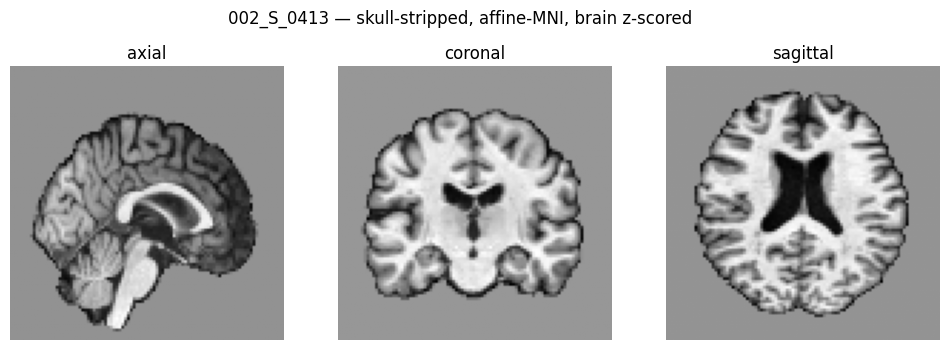


→ Brain should fill the frame with TRUE BLACK background (nonzero frac ~0.2-0.4).
→ If you still see skull/neck, STOP and report to Claude.


In [ ]:
import matplotlib.pyplot as plt, time
test_pid=patients[0]
t=time.time(); status,info=preprocess_one(test_pid); dt=time.time()-t
print(f'{test_pid}: status={status} time={dt:.1f}s info={info}')
assert status=='ok', f'Smoke test failed: {status}. Fix before full run.'
v=np.load(os.path.join(OUT_DIR, f'{test_pid}_processed.npy'))
print('saved vol:', v.shape, 'nonzero frac:', float((v!=0).mean()))
d,h,w=v.shape
fig,ax=plt.subplots(1,3,figsize=(12,4))
ax[0].imshow(np.rot90(v[d//2]),cmap='gray'); ax[0].set_title('axial')
ax[1].imshow(np.rot90(v[:,h//2]),cmap='gray'); ax[1].set_title('coronal')
ax[2].imshow(np.rot90(v[:,:,w//2]),cmap='gray'); ax[2].set_title('sagittal')
for a in ax: a.axis('off')
plt.suptitle(f'{test_pid} — skull-stripped, affine-MNI, brain z-scored'); plt.show()
print('\n→ Brain should fill the frame with TRUE BLACK background (nonzero frac ~0.2-0.4).')
print('→ If you still see skull/neck, STOP and report to Claude.')

## 6. Full run (checkpointed)

Processes all patients, skipping any already saved. Re-runnable after a disconnect. Logs每 patient to `prep_log.jsonl`.

In [5]:
from tqdm.notebook import tqdm
import glob as _glob
def glob_all(pid):
    return _glob.glob(os.path.join(WORK, f"{pid}*"))

done=set(os.path.splitext(f)[0].replace("_processed","") for f in os.listdir(OUT_DIR) if f.endswith(".npy"))
todo=[p for p in patients if p not in done]
print(f"Already done: {len(done)} | remaining: {len(todo)}")

counts={"ok":0,"no_raw":0,"hdbet_fail":0,"empty_brain":0,"error":0}
for pid in tqdm(todo, desc="preprocess"):
    try:
        status,info=preprocess_one(pid)
    except Exception as e:
        status,info="error",str(e)[-300:]
    counts[status]=counts.get(status,0)+1
    log_entry={"ts":datetime.datetime.now().isoformat(),"pid":pid,"status":status,"info":info}
    with open(LOG_PATH,"a") as f:
        f.write(json.dumps(log_entry)+"\n")
    for tmp in glob_all(pid):
        try: os.remove(tmp)
        except: pass
print("Done. Status counts:", counts)

Already done: 187 | remaining: 0


preprocess: 0it [00:00, ?it/s]

Done. Status counts: {'ok': 0, 'no_raw': 0, 'hdbet_fail': 0, 'empty_brain': 0, 'error': 0}


## 7. Verify output & compare to old preprocessing

In [6]:
out_files=[f for f in os.listdir(OUT_DIR) if f.endswith('.npy')]
print(f'Total processed volumes: {len(out_files)} / {len(patients)}')

# intensity-consistency check: the OLD data had wildly different bright-fractions per patient.
# After brain z-score, distributions should be much more consistent.
import numpy as np
stats=[]
for f in out_files[:20]:
    v=np.load(os.path.join(OUT_DIR,f)); m=v!=0
    stats.append((float((v!=0).mean()), float(v[m].mean()), float(v[m].std())))
stats=np.array(stats)
print('Across 20 volumes (should be CONSISTENT now):')
print(f'  nonzero frac: mean={stats[:,0].mean():.3f} std={stats[:,0].std():.3f}')
print(f'  in-brain mean: mean={stats[:,1].mean():.3f} std={stats[:,1].std():.3f}  (z-scored -> near 0)')
print(f'  in-brain std : mean={stats[:,2].mean():.3f} std={stats[:,2].std():.3f}  (z-scored -> near 1)')
print('\n✅ If nonzero-frac std is small and in-brain mean~0 std~1, harmonization worked.')
print('Next: run Condition 3b (training) pointing PROCESSED_MRI_DIRECTORY at processed_mri_scans_brain.')

Total processed volumes: 187 / 187
Across 20 volumes (should be CONSISTENT now):
  nonzero frac: mean=0.265 std=0.003
  in-brain mean: mean=0.000 std=0.000  (z-scored -> near 0)
  in-brain std : mean=0.936 std=0.002  (z-scored -> near 1)

✅ If nonzero-frac std is small and in-brain mean~0 std~1, harmonization worked.
Next: run Condition 3b (training) pointing PROCESSED_MRI_DIRECTORY at processed_mri_scans_brain.
